# Human Activity Recognition with Hidden Markov Models

**Full pipeline:** 
- Part 1 (data collection, preprocessing, feature extraction) BY Jade ISIMBI TUZINDE
- Part 2 (HMM implementation, Viterbi, Baum–Welch, evaluation on unseen data) BY Davy NGAMIJE RUHUMULIZA



# PART 1 (data collection, preprocessing, feature extraction)

## 1. Setup and paths

In [52]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt
from pathlib import Path

np.random.seed(42)
sns.set_theme(style="whitegrid")


PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIRS = ["data/raw/raw_data", "data/raw/raw_data2"]
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


TARGET_HZ = 50   
WINDOW_SEC = 1.0 
STEP_SEC = 0.5   

print("Project root:", PROJECT_ROOT)
print("Processed output:", OUTPUT_DIR)

Project root: /Users/jade/Hidden_Markov_Models
Processed output: /Users/jade/Hidden_Markov_Models/data/processed


## 2. Discover recordings and infer activity labels

In [53]:
def get_activity_from_folder_name(folder_name):
    """Normalize folder name to one of: standing, walking, jumping, still."""
    base = os.path.basename(folder_name).lower()
    # Remove trailing date/time 
    base = re.sub(r"-\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}.*", "", base)
    base = re.sub(r"\s+", "_", base)
    if base.startswith("standing"): return "standing"
    if base.startswith("walking"): return "walking"
    if base.startswith("jumping"): return "jumping"
    if base.startswith("still"): return "still"
    return None

def list_recording_folders():
    """List (folder_path, activity) for each recording. Skips nested folders (e.g. still_5 inside jumping_6)."""
    records = []
    for data_dir in RAW_DATA_DIRS:
        root = PROJECT_ROOT / data_dir
        if not root.exists():
            continue
        for name in sorted(os.listdir(root)):
            path = root / name
            if not path.is_dir():
                continue
            
            acc = path / "Accelerometer.csv"
            gyr = path / "Gyroscope.csv"
            if not acc.exists() or not gyr.exists():
                continue
            activity = get_activity_from_folder_name(name)
            if activity is None:
                continue
            records.append((str(path), activity, data_dir))
    return records

recordings = list_recording_folders()
print(f"Total recordings: {len(recordings)}")
for act in ["standing", "walking", "jumping", "still"]:
    n = sum(1 for _, a, _ in recordings if a == act)
    print(f"  {act}: {n}")

Total recordings: 50
  standing: 13
  walking: 12
  jumping: 12
  still: 13


## 3. Load one recording: merge Accelerometer and Gyroscope

In [54]:
def load_one_recording(folder_path):
    """Load Accelerometer and Gyroscope, merge on seconds_elapsed. Returns DataFrame with time index."""
    path = Path(folder_path)
    acc = pd.read_csv(path / "Accelerometer.csv")
    gyr = pd.read_csv(path / "Gyroscope.csv")
    acc = acc.rename(columns={"x": "acc_x", "y": "acc_y", "z": "acc_z"})
    gyr = gyr.rename(columns={"x": "gyr_x", "y": "gyr_y", "z": "gyr_z"})
    acc = acc[["seconds_elapsed", "acc_x", "acc_y", "acc_z"]].drop_duplicates(subset=["seconds_elapsed"])
    gyr = gyr[["seconds_elapsed", "gyr_x", "gyr_y", "gyr_z"]].drop_duplicates(subset=["seconds_elapsed"])
    df = pd.merge(acc, gyr, on="seconds_elapsed", how="inner")
    df = df.sort_values("seconds_elapsed").reset_index(drop=True)
    df["time"] = df["seconds_elapsed"]
    df = df.set_index("time")
    return df

# Quick test
sample_path = recordings[0][0]
sample_df = load_one_recording(sample_path)
print("Sample recording shape:", sample_df.shape)
print(sample_df.head())

Sample recording shape: (1057, 7)
          seconds_elapsed     acc_x     acc_y     acc_z     gyr_x     gyr_y  \
time                                                                          
0.079177         0.079177  0.306734 -0.272964 -0.232869 -0.006184 -0.143767   
0.089175         0.089175  0.255809 -0.271763 -0.176157  0.029789 -0.154137   
0.099173         0.099173  0.123803 -0.266145 -0.120043  0.030607 -0.146607   
0.109171         0.109171 -0.011775 -0.259245 -0.100614  0.023972 -0.108839   
0.119169         0.119169 -0.127590 -0.305385 -0.184352  0.028648 -0.063430   

             gyr_z  
time                
0.079177  0.048352  
0.089175  0.050756  
0.099173  0.034759  
0.109171  0.006692  
0.119169 -0.033764  


## 4. Sampling rate


In [55]:
def estimate_sampling_rate(df):
    """Estimate Hz from consecutive time differences."""
    t = df.index.values
    if len(t) < 2:
        return np.nan
    dt = np.diff(t)
    dt_median = np.median(dt)
    if dt_median <= 0:
        return np.nan
    return 1.0 / dt_median

def resample_to_target(df, target_hz=TARGET_HZ):
    """Resample to target_hz using linear interpolation (index = seconds)."""
    duration = df.index.max() - df.index.min()
    if duration <= 0:
        return df
    n_samples = int(round(duration * target_hz))
    new_index = np.linspace(df.index.min(), df.index.max(), n_samples)
    return df.reindex(df.index.union(new_index)).interpolate(method="linear").loc[new_index]

# Report sampling rate per recording 
rates = []
for folder_path, activity, source in recordings:
    df = load_one_recording(folder_path)
    hz = estimate_sampling_rate(df)
    duration = df.index.max() - df.index.min() if len(df) > 1 else 0
    rates.append({"folder": Path(folder_path).name, "activity": activity, "source": source, "hz": hz, "duration_sec": duration})

rates_df = pd.DataFrame(rates)
print("Sampling rate (Hz) per recording (use this for your report table):")
print(rates_df.groupby(["source", "activity"]).agg({"hz": ["min", "max", "mean"], "duration_sec": "sum"}).round(2))
print("\nTotal duration per activity (seconds):")
print(rates_df.groupby("activity")["duration_sec"].sum().round(1))

Sampling rate (Hz) per recording (use this for your report table):
                                 hz                 duration_sec
                                min     max    mean          sum
source             activity                                     
data/raw/raw_data  jumping   100.02  100.02  100.02        63.39
                   standing  100.02  100.02  100.02        63.82
                   still     100.02  100.03  100.03        75.43
                   walking   100.02  100.02  100.02        62.54
data/raw/raw_data2 jumping    99.71   99.71   99.71        59.64
                   standing   99.70   99.72   99.71        69.72
                   still      99.71   99.72   99.72        59.71
                   walking    99.70   99.70   99.70        59.80

Total duration per activity (seconds):
activity
jumping     123.0
standing    133.5
still       135.1
walking     122.3
Name: duration_sec, dtype: float64


## 5. Windowing: rationale and implementation



In [56]:
def highpass_filter(df, cutoff_hz=0.5, fs=50.0, order=3):
    """Apply high-pass Butterworth to remove DC and very low frequency. Helps separate jumping (dynamic) from still."""
    signal_cols = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]
    cols = [c for c in signal_cols if c in df.columns]
    if len(cols) == 0 or len(df) < 2 * order + 1:
        return df
    nyq = 0.5 * fs
    low = cutoff_hz / nyq
    if low >= 1:
        return df
    b, a = butter(order, low, btype="high")
    out = df.copy()
    for c in cols:
        out[c] = filtfilt(b, a, df[c].values)
    return out

def build_windows(df, window_sec=WINDOW_SEC, step_sec=STEP_SEC, target_hz=TARGET_HZ):
    """Split resampled DataFrame into overlapping windows. Returns list of (start_time, end_time, slice_df)."""
    df = resample_to_target(df, target_hz)
    df = highpass_filter(df, cutoff_hz=0.5, fs=target_hz, order=3)
    t = df.index.values
    if len(t) < 2:
        return []
    window_samples = int(round(window_sec * target_hz))
    step_samples = int(round(step_sec * target_hz))
    if step_samples < 1:
        step_samples = 1
    windows = []
    start = 0
    while start + window_samples <= len(df):
        end = start + window_samples
        w = df.iloc[start:end]
        windows.append((w.index.min(), w.index.max(), w))
        start += step_samples
    return windows

# Test on one recording
test_df = load_one_recording(recordings[0][0])
test_df = resample_to_target(test_df, TARGET_HZ)
windows = build_windows(test_df, WINDOW_SEC, STEP_SEC, TARGET_HZ)
print(f"Recording length: {len(test_df)} samples ({test_df.index.max() - test_df.index.min():.2f} s)")
print(f"Number of windows: {len(windows)}")

Recording length: 528 samples (10.56 s)
Number of windows: 20


## 6. Feature extraction




In [57]:
SIGNAL_COLS = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]

def time_domain_features(w):
    """Compute time-domain features per window (w = DataFrame slice)."""
    out = {}
    for col in SIGNAL_COLS:
        out[f"mean_{col}"] = w[col].mean()
        out[f"var_{col}"] = w[col].var()
        out[f"std_{col}"] = w[col].std()
    # SMA for acc and gyr separately (typical in HAR)
    out["sma_acc"] = (w[["acc_x", "acc_y", "acc_z"]].abs().sum(axis=1)).mean()
    out["sma_gyr"] = (w[["gyr_x", "gyr_y", "gyr_z"]].abs().sum(axis=1)).mean()
    # Correlations between axes (accelerometer); use 0 when constant column gives NaN
    def safe_corr(a, b):
        c = w[[a, b]].corr().iloc[0, 1]
        return float(c) if np.isfinite(c) else 0.0
    out["corr_acc_xy"] = safe_corr("acc_x", "acc_y")
    out["corr_acc_xz"] = safe_corr("acc_x", "acc_z")
    out["corr_acc_yz"] = safe_corr("acc_y", "acc_z")

    acc_mag = np.sqrt((w[["acc_x", "acc_y", "acc_z"]] ** 2).sum(axis=1))
    out["peak_acc"] = acc_mag.max()
    
    for col in SIGNAL_COLS:
        out[f"range_{col}"] = w[col].max() - w[col].min()
    
    mag_centered = acc_mag - acc_mag.mean()
    zcr = np.sum(np.abs(np.diff(np.sign(mag_centered)))) / 2.0 / max(1, len(mag_centered) - 1)
    out["zcr_acc"] = float(zcr) if np.isfinite(zcr) else 0.0

    out["var_acc_mag"] = acc_mag.var() if len(acc_mag) > 1 else 0.0
    return out

def frequency_domain_features(w, cols=None):
    """FFT-derived features. cols: which columns to use (default: acc_x for dominant freq and energy)."""
    if cols is None:
        cols = ["acc_x", "acc_y", "acc_z"]
    out = {}
    for col in cols:
        x = w[col].values
        n = len(x)
        if n < 4:
            out[f"dom_freq_{col}"] = 0.0
            out[f"spectral_energy_{col}"] = 0.0
            continue
        yf = fft(x)
        freqs = fftfreq(n, 1.0 / TARGET_HZ)
        pos_mask = freqs > 0
        freqs_pos = freqs[pos_mask]
        mag = np.abs(yf[pos_mask])
        if len(mag) == 0:
            out[f"dom_freq_{col}"] = 0.0
            out[f"spectral_energy_{col}"] = 0.0
            continue
        idx_max = np.argmax(mag)
        out[f"dom_freq_{col}"] = freqs_pos[idx_max]
        # Spectral energy: sum of squared magnitudes in 0.5--5 Hz (typical for human motion)
        band = (freqs_pos >= 0.5) & (freqs_pos <= 5.0)
        out[f"spectral_energy_{col}"] = np.sum(mag[band] ** 2)
        # High-frequency energy (3--10 Hz): impacts/jumping vs still (flat spectrum)
        band_high = (freqs_pos >= 3.0) & (freqs_pos <= 10.0)
        out[f"spectral_energy_high_{col}"] = np.sum(mag[band_high] ** 2)
    return out

def extract_features_for_window(w):
    """One feature vector per window."""
    feats = time_domain_features(w)
    feats.update(frequency_domain_features(w, cols=["acc_x", "acc_y", "acc_z"]))
    return feats

In [170]:
# Build ordered feature names (for consistent columns)
def get_feature_names():
    w = pd.DataFrame({c: [0.0] * 50 for c in SIGNAL_COLS})
    f = extract_features_for_window(w)
    return list(f.keys())

FEATURE_NAMES = get_feature_names()
print("Number of features:", len(FEATURE_NAMES))
print("Time-domain (mean/var/std/sma/corr):", [n for n in FEATURE_NAMES if "dom_freq" not in n and "spectral_energy" not in n])
print("Frequency-domain (FFT):", [n for n in FEATURE_NAMES if "dom_freq" in n or "spectral_energy" in n])

Number of features: 41
Time-domain (mean/var/std/sma/corr): ['mean_acc_x', 'var_acc_x', 'std_acc_x', 'mean_acc_y', 'var_acc_y', 'std_acc_y', 'mean_acc_z', 'var_acc_z', 'std_acc_z', 'mean_gyr_x', 'var_gyr_x', 'std_gyr_x', 'mean_gyr_y', 'var_gyr_y', 'std_gyr_y', 'mean_gyr_z', 'var_gyr_z', 'std_gyr_z', 'sma_acc', 'sma_gyr', 'corr_acc_xy', 'corr_acc_xz', 'corr_acc_yz', 'peak_acc', 'range_acc_x', 'range_acc_y', 'range_acc_z', 'range_gyr_x', 'range_gyr_y', 'range_gyr_z', 'zcr_acc', 'var_acc_mag']
Frequency-domain (FFT): ['dom_freq_acc_x', 'spectral_energy_acc_x', 'spectral_energy_high_acc_x', 'dom_freq_acc_y', 'spectral_energy_acc_y', 'spectral_energy_high_acc_y', 'dom_freq_acc_z', 'spectral_energy_acc_z', 'spectral_energy_high_acc_z']


## 7. Normalization (Z-score)




In [58]:
from sklearn.preprocessing import StandardScaler

# We'll fit scaler on training feature matrix later; placeholder here.
def normalize_features(X_train, X_test=None):
    """Z-score: fit on X_train, transform train and (if provided) test."""
    scaler = StandardScaler()
    X_train_n = scaler.fit_transform(X_train)
    if X_test is not None:
        X_test_n = scaler.transform(X_test)
        return X_train_n, X_test_n, scaler
    return X_train_n, None, scaler

## 8. Build full dataset: observation sequences and labels



In [59]:
ACTIVITY_TO_ID = {"standing": 0, "walking": 1, "jumping": 2, "still": 3}
ID_TO_ACTIVITY = {v: k for k, v in ACTIVITY_TO_ID.items()}

def process_all_recordings(recordings_list, window_sec=WINDOW_SEC, step_sec=STEP_SEC, target_hz=TARGET_HZ):
    """Returns: list of (observation_sequence, label_sequence) per recording."""
    all_sequences = []  # list of (X, y) where X = (n_windows, n_features), y = (n_windows,)
    for folder_path, activity, _ in recordings_list:
        df = load_one_recording(folder_path)
        windows = build_windows(df, window_sec, step_sec, target_hz)
        if not windows:
            continue
        rows = []
        for _, _, w in windows:
            feats = extract_features_for_window(w)
            rows.append([feats[k] for k in FEATURE_NAMES])
        X = np.array(rows)
        y = np.full(len(rows), ACTIVITY_TO_ID[activity])
        all_sequences.append((X, y, activity, folder_path))
    return all_sequences

all_sequences = process_all_recordings(recordings)
print(f"Total recordings processed: {len(all_sequences)}")
total_windows = sum(X.shape[0] for X, y, _, _ in all_sequences)
print(f"Total windows: {total_windows}")

Total recordings processed: 50
Total windows: 946


In [60]:
# Train/test split: hold out 2 recordings from 2 *different* activities (so test set has multiple activities for per-activity metrics)
def train_test_split_recordings_stratified(sequences, test_count=4, seed=42):
    """Pick one recording per activity for test (test_count activities); default 4 = one per activity."""
    rng = np.random.default_rng(seed)
    by_activity = {}
    for i, s in enumerate(sequences):
        act = s[2]
        by_activity.setdefault(act, []).append(i)
    activities = list(by_activity.keys())
    rng.shuffle(activities)
    test_idx = set()
    for act in activities[:test_count]:
        idx = rng.choice(by_activity[act])
        test_idx.add(idx)
    train_seq = [s for i, s in enumerate(sequences) if i not in test_idx]
    test_seq = [s for i, s in enumerate(sequences) if i in test_idx]
    return train_seq, test_seq

train_sequences, test_sequences = train_test_split_recordings_stratified(all_sequences, test_count=4)
print(f"Train recordings: {len(train_sequences)}, Test recordings: {len(test_sequences)}")
if test_sequences:
    test_activities = [s[2] for s in test_sequences]
    print("Test recording activities (one per activity):", test_activities)
    assert len(set(test_activities)) == 4, "Test set should have one recording per activity (4 activities)"

Train recordings: 46, Test recordings: 4
Test recording activities (one per activity): ['jumping', 'still', 'walking', 'standing']


In [61]:
# Stack train/test and normalize
def stack_sequences(seq_list):
    X_list = [s[0] for s in seq_list]
    y_list = [s[1] for s in seq_list]
    return np.vstack(X_list), np.concatenate(y_list)

X_train_full, y_train_full = stack_sequences(train_sequences)
if test_sequences:
    X_test_full, y_test_full = stack_sequences(test_sequences)
else:
    X_test_full = np.empty((0, len(FEATURE_NAMES)))
    y_test_full = np.array([])

X_train_n, X_test_n, scaler = normalize_features(X_train_full, X_test_full if len(X_test_full) > 0 else None)

print("Train shape:", X_train_n.shape)
print("Test shape:", X_test_n.shape if X_test_n is not None else (0, X_train_n.shape[1]))

# Save scaler and feature names for Part 2
import pickle
with open(OUTPUT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump({"scaler": scaler, "feature_names": FEATURE_NAMES, "activity_to_id": ACTIVITY_TO_ID}, f)
np.save(OUTPUT_DIR / "feature_names.npy", np.array(FEATURE_NAMES))
np.save(OUTPUT_DIR / "activity_to_id.npy", np.array(list(ACTIVITY_TO_ID.items())))

Train shape: (867, 41)
Test shape: (79, 41)


In [62]:
# Export observation sequences for Part 2: list of (X_normalized) per recording (train and test)
def normalized_sequences_for_hmm(train_sequences, test_sequences, scaler):
    train_obs = []
    train_labels = []
    for X, y, _, _ in train_sequences:
        X_n = scaler.transform(X)
        train_obs.append(X_n)
        train_labels.append(y)
    test_obs = []
    test_labels = []
    for X, y, _, _ in test_sequences:
        X_n = scaler.transform(X)
        test_obs.append(X_n)
        test_labels.append(y)
    return train_obs, train_labels, test_obs, test_labels

train_obs, train_labels, test_obs, test_labels = normalized_sequences_for_hmm(train_sequences, test_sequences, scaler)

with open(OUTPUT_DIR / "train_observation_sequences.pkl", "wb") as f:
    pickle.dump({"sequences": train_obs, "labels": train_labels}, f)
with open(OUTPUT_DIR / "test_observation_sequences.pkl", "wb") as f:
    pickle.dump({"sequences": test_obs, "labels": test_labels}, f)

print("Saved train/test observation sequences and scaler to", OUTPUT_DIR)

Saved train/test observation sequences and scaler to /Users/jade/Hidden_Markov_Models/data/processed


## 9. Visualizations of sample data 


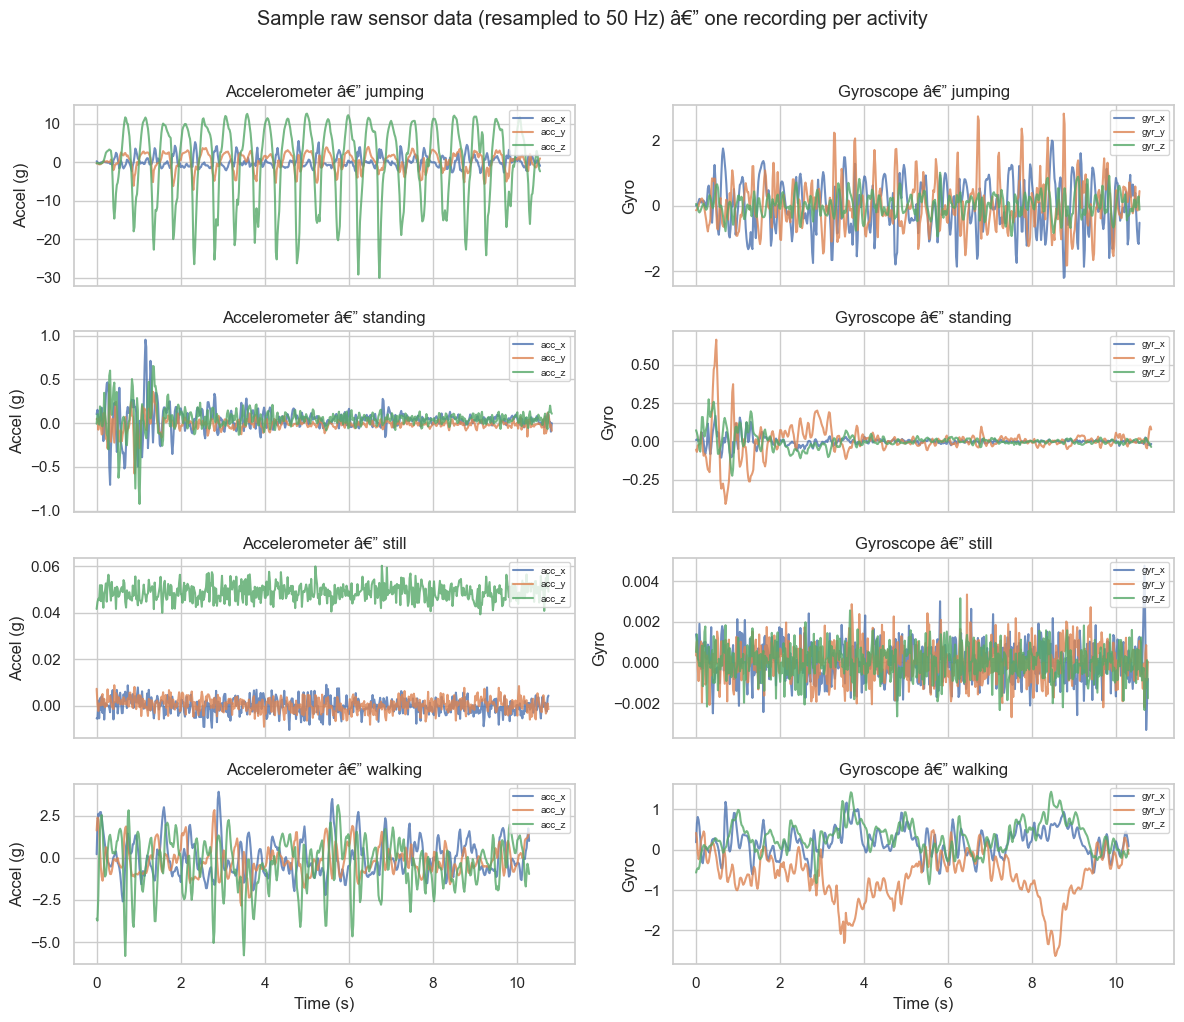

In [63]:
# Pick one recording per activity for plotting
sample_per_activity = {}
for folder_path, activity, _ in recordings:
    if activity not in sample_per_activity:
        sample_per_activity[activity] = (folder_path, activity)
    if len(sample_per_activity) == 4:
        break

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
for row, (activity, (folder_path, _)) in enumerate(sample_per_activity.items()):
    df = load_one_recording(folder_path)
    df = resample_to_target(df, TARGET_HZ)
    t = df.index.values - df.index.min()
    axes[row, 0].plot(t, df["acc_x"], label="acc_x", alpha=0.8)
    axes[row, 0].plot(t, df["acc_y"], label="acc_y", alpha=0.8)
    axes[row, 0].plot(t, df["acc_z"], label="acc_z", alpha=0.8)
    axes[row, 0].set_ylabel("Accel (g)")
    axes[row, 0].set_title(f"Accelerometer â€” {activity}")
    axes[row, 0].legend(loc="upper right", fontsize=7)
    axes[row, 1].plot(t, df["gyr_x"], label="gyr_x", alpha=0.8)
    axes[row, 1].plot(t, df["gyr_y"], label="gyr_y", alpha=0.8)
    axes[row, 1].plot(t, df["gyr_z"], label="gyr_z", alpha=0.8)
    axes[row, 1].set_ylabel("Gyro")
    axes[row, 1].set_title(f"Gyroscope â€” {activity}")
    axes[row, 1].legend(loc="upper right", fontsize=7)
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.suptitle("Sample raw sensor data (resampled to 50 Hz) â€” one recording per activity", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_data_per_activity.png", dpi=150, bbox_inches="tight")
plt.show()

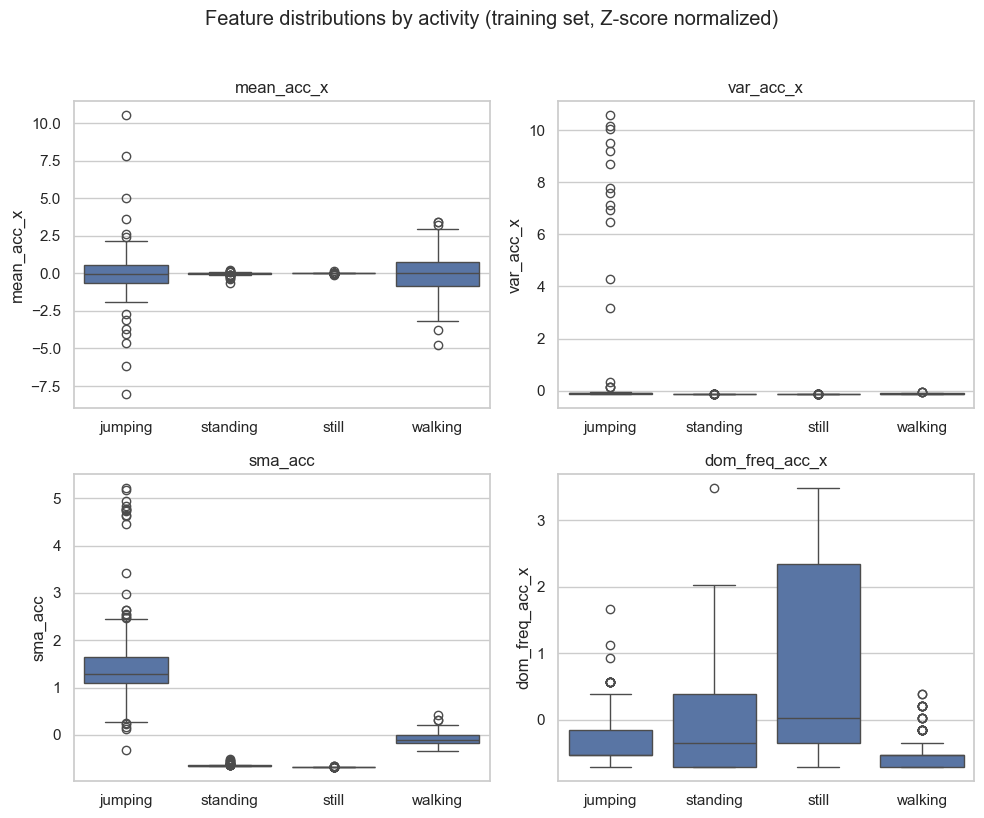

In [64]:
# Feature distributions per activity (training set) â€” shows that features discriminate activities
train_X, train_y = stack_sequences(train_sequences)
train_X_n, _, _ = normalize_features(train_X)
feat_df = pd.DataFrame(train_X_n, columns=FEATURE_NAMES)
feat_df["activity"] = [ID_TO_ACTIVITY[i] for i in train_y]

# Plot a subset: mean acc_x, var acc_x, sma_acc, dom_freq_acc_x
subset = ["mean_acc_x", "var_acc_x", "sma_acc", "dom_freq_acc_x"]
subset = [c for c in subset if c in feat_df.columns]
if len(subset) >= 2:
    fig2, ax2 = plt.subplots(2, 2, figsize=(10, 8))
    ax2 = ax2.ravel()
    for i, col in enumerate(subset[:4]):
        sns.boxplot(data=feat_df, x="activity", y=col, ax=ax2[i])
        ax2[i].set_title(col)
        ax2[i].set_xlabel("")
    plt.suptitle("Feature distributions by activity (training set, Z-score normalized)", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_distributions_by_activity.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10. Save cleaned dataset 

Save CSV with one row per window: `file_id`, `activity`, `t_start`, `t_end`, and all feature columns (normalized). T

In [65]:
rows = []
for folder_path, activity, _ in recordings:
    df = load_one_recording(folder_path)
    windows = build_windows(df, WINDOW_SEC, STEP_SEC, TARGET_HZ)
    for t_start, t_end, w in windows:
        feats = extract_features_for_window(w)
        row = {"file": Path(folder_path).name, "activity": activity, "t_start": t_start, "t_end": t_end}
        row.update(feats)
        rows.append(row)

full_df = pd.DataFrame(rows)
feature_cols = [c for c in full_df.columns if c not in ("file", "activity", "t_start", "t_end")]
full_df["activity_id"] = full_df["activity"].map(ACTIVITY_TO_ID)
# Normalize features (fit on full - for export only; Part 2 uses train-fit scaler)
scaler_export = StandardScaler()
full_df[feature_cols] = scaler_export.fit_transform(full_df[feature_cols])
full_df.to_csv(OUTPUT_DIR / "cleaned_labeled_windows.csv", index=False)
print("Saved", len(full_df), "rows to", OUTPUT_DIR / "cleaned_labeled_windows.csv")
print("Activities:", full_df["activity"].value_counts().to_dict())

Saved 946 rows to /Users/jade/Hidden_Markov_Models/data/processed/cleaned_labeled_windows.csv
Activities: {'still': 250, 'standing': 245, 'walking': 226, 'jumping': 225}


# Part 2: Hidden Markov Model Implementation and Evaluation

**Goal:** Implement HMM with Viterbi decoding and Baum-Welch training, evaluate on unseen test data, and report results.

**Structure:**
1. Load preprocessed data from Part 1
2. Implement HMM class (Viterbi + Baum-Welch)
3. Train model on training sequences
4. Evaluate on unseen test data
5. Visualizations and metrics
6. Report sections

## 1. Setup and Load Processed Data

In [66]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import multivariate_normal
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style="whitegrid")

# Paths
PROJECT_ROOT = Path("..").resolve()  # Go up one level from notebooks folder
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROCESSED_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", PROCESSED_DIR)

Project root: /Users/jade/Hidden_Markov_Models
Processed data directory: /Users/jade/Hidden_Markov_Models/data/processed


In [67]:
# Load preprocessed data from Part 1
with open(PROCESSED_DIR / "train_observation_sequences.pkl", "rb") as f:
    train_sequences = pickle.load(f)

with open(PROCESSED_DIR / "test_observation_sequences.pkl", "rb") as f:
    test_sequences = pickle.load(f)

with open(PROCESSED_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

FEATURE_NAMES = np.load(PROCESSED_DIR / "feature_names.npy", allow_pickle=True)

# Load activity mapping (handle different save formats)
activity_mapping_loaded = np.load(PROCESSED_DIR / "activity_to_id.npy", allow_pickle=True)

# Convert to dictionary based on file format
if isinstance(activity_mapping_loaded, np.ndarray):
    if activity_mapping_loaded.ndim == 2:
        # 2D array format: [['activity_name', 'id'], ...]
        # Keep activity names exactly as they are (e.g., "standing_1", "walking_2", etc.)
        activity_mapping = {str(row[0]): int(row[1]) for row in activity_mapping_loaded}
    elif activity_mapping_loaded.ndim == 0:
        # 0D array (scalar) - extract the item
        activity_mapping = activity_mapping_loaded.item()
    elif activity_mapping_loaded.size == 1:
        # 1D array with single element
        activity_mapping = activity_mapping_loaded.item()
    else:
        # Try to convert directly
        activity_mapping = dict(activity_mapping_loaded)
elif isinstance(activity_mapping_loaded, dict):
    activity_mapping = activity_mapping_loaded
else:
    raise ValueError(f"Unknown format for activity_to_id.npy: {type(activity_mapping_loaded)}")

# Reverse mapping: id -> activity
ID_TO_ACTIVITY = {v: k for k, v in activity_mapping.items()}
N_STATES = len(activity_mapping)

# Convert dictionary format to list of tuples if needed
if isinstance(train_sequences, dict) and 'sequences' in train_sequences:
    train_sequences = list(zip(train_sequences['sequences'], train_sequences['labels']))

if isinstance(test_sequences, dict) and 'sequences' in test_sequences:
    test_sequences = list(zip(test_sequences['sequences'], test_sequences['labels']))

print(f"Loaded {len(train_sequences)} training sequences")
print(f"Loaded {len(test_sequences)} test sequences")
print(f"Number of features: {len(FEATURE_NAMES)}")
print(f"Number of states (activities): {N_STATES}")
print(f"Activity mapping: {activity_mapping}")
print(f"Activities: {list(ID_TO_ACTIVITY.values())}")
print(f"\nNote: Activity names come from Part 1's activity_to_id.npy file.")

Loaded 46 training sequences
Loaded 4 test sequences
Number of features: 41
Number of states (activities): 4
Activity mapping: {'standing': 0, 'walking': 1, 'jumping': 2, 'still': 3}
Activities: ['standing', 'walking', 'jumping', 'still']

Note: Activity names come from Part 1's activity_to_id.npy file.


## 2. HMM Model Definition

**Hidden States (Z):** 4 activities (standing, walking, jumping, still)

**Observations (X):** Feature vectors from Part 1 (time & frequency domain features)

**Parameters:**
- **A** (Transition probabilities): N_states Ã— N_states matrix
- **B** (Emission probabilities): Gaussian distribution per state (mean and covariance)
- **Ï€** (Initial state probabilities): N_states vector

**Emission Model:** Multivariate Gaussian for each state

**Key Implementation Improvements:**
1. **Supervised Initialization**: Uses labeled training data to initialize emission means (Î¼), covariances (Î£), transitions (A), and initial probabilities (Ï€) based on per-activity statistics
2. **Covariance Regularization**: Adds ÎµÂ·I (Îµ=1e-6) to covariance matrices to ensure positive definiteness and numerical stability
3. **Robust Convergence**: Stops when |Î”LL| < 1e-4 (not just max iterations), ensuring proper convergence
4. **Numerical Stability**: Log-space computation in Viterbi to prevent underflow

## 3. Hidden Markov Model Implementation

In [68]:
class GaussianHMM:
    """
    Hidden Markov Model with Gaussian emissions.
    
    Implements:
    - Viterbi algorithm for decoding (finding most likely state sequence)
    - Baum-Welch algorithm for parameter learning (training)
    """
    
    def __init__(self, n_states, n_features):
        """
        Initialize HMM with random parameters.
        
        Args:
            n_states: Number of hidden states
            n_features: Dimension of observation vectors
        """
        self.n_states = n_states
        self.n_features = n_features
        
        # Initialize parameters randomly
        self.pi = np.ones(n_states) / n_states  # Uniform initial distribution
        self.A = np.ones((n_states, n_states)) / n_states  # Uniform transitions
        
        # Gaussian emission parameters (mean and covariance per state)
        self.means = np.random.randn(n_states, n_features) * 0.1
        self.covs = np.array([np.eye(n_features) for _ in range(n_states)])
        
        self.log_likelihoods = []  # Track training progress
        
    def _emission_prob(self, obs, state):
        """
        Compute P(observation | state) using multivariate Gaussian.
        
        Args:
            obs: Observation vector (n_features,)
            state: State index
            
        Returns:
            Emission probability
        """
        try:
            prob = multivariate_normal.pdf(obs, mean=self.means[state], cov=self.covs[state])
            # Prevent numerical underflow
            return max(prob, 1e-10)
        except:
            return 1e-10
    
    def viterbi(self, observations):
        """
        Viterbi algorithm: find most likely state sequence.
        
        Args:
            observations: Sequence of observation vectors (T, n_features)
            
        Returns:
            Most likely state sequence (T,)
        """
        T = len(observations)
        
        # Initialize Viterbi table and backpointers
        viterbi = np.zeros((T, self.n_states))
        backpointer = np.zeros((T, self.n_states), dtype=int)
        
        # Initialization (t=0)
        for s in range(self.n_states):
            viterbi[0, s] = np.log(self.pi[s] + 1e-10) + np.log(self._emission_prob(observations[0], s))
        
        # Recursion (t=1 to T-1)
        for t in range(1, T):
            for s in range(self.n_states):
                # Find max over previous states
                trans_probs = viterbi[t-1] + np.log(self.A[:, s] + 1e-10)
                backpointer[t, s] = np.argmax(trans_probs)
                viterbi[t, s] = trans_probs[backpointer[t, s]] + np.log(self._emission_prob(observations[t], s))
        
        # Termination: find best final state
        best_path = np.zeros(T, dtype=int)
        best_path[T-1] = np.argmax(viterbi[T-1])
        
        # Backtrack to find full path
        for t in range(T-2, -1, -1):
            best_path[t] = backpointer[t+1, best_path[t+1]]
        
        return best_path
    
    def _forward(self, observations):
        """
        Forward algorithm: compute forward probabilities Î±.
        
        Args:
            observations: Sequence of observation vectors (T, n_features)
            
        Returns:
            alpha: Forward probabilities (T, n_states)
            log_likelihood: Log P(observations | model)
        """
        T = len(observations)
        alpha = np.zeros((T, self.n_states))
        
        # Initialization
        for s in range(self.n_states):
            alpha[0, s] = self.pi[s] * self._emission_prob(observations[0], s)
        
        # Normalize to prevent underflow
        alpha[0] /= (alpha[0].sum() + 1e-10)
        
        # Recursion
        for t in range(1, T):
            for s in range(self.n_states):
                alpha[t, s] = np.sum(alpha[t-1] * self.A[:, s]) * self._emission_prob(observations[t], s)
            alpha[t] /= (alpha[t].sum() + 1e-10)
        
        log_likelihood = np.sum(np.log(alpha.sum(axis=1) + 1e-10))
        return alpha, log_likelihood
    
    def _backward(self, observations):
        """
        Backward algorithm: compute backward probabilities Î².
        
        Args:
            observations: Sequence of observation vectors (T, n_features)
            
        Returns:
            beta: Backward probabilities (T, n_states)
        """
        T = len(observations)
        beta = np.zeros((T, self.n_states))
        
        # Initialization
        beta[T-1] = 1.0
        
        # Recursion (backward)
        for t in range(T-2, -1, -1):
            for s in range(self.n_states):
                beta[t, s] = np.sum(self.A[s, :] * 
                                   np.array([self._emission_prob(observations[t+1], s2) for s2 in range(self.n_states)]) * 
                                   beta[t+1])
            beta[t] /= (beta[t].sum() + 1e-10)
        
        return beta
    
    def _compute_gamma_xi(self, observations, alpha, beta):
        """
        Compute Î³ (state occupation) and Î¾ (state transition) probabilities.
        
        Args:
            observations: Sequence of observation vectors (T, n_features)
            alpha: Forward probabilities (T, n_states)
            beta: Backward probabilities (T, n_states)
            
        Returns:
            gamma: State occupation probabilities (T, n_states)
            xi: State transition probabilities (T-1, n_states, n_states)
        """
        T = len(observations)
        gamma = np.zeros((T, self.n_states))
        xi = np.zeros((T-1, self.n_states, self.n_states))
        
        # Compute gamma
        for t in range(T):
            gamma[t] = alpha[t] * beta[t]
            gamma[t] /= (gamma[t].sum() + 1e-10)
        
        # Compute xi
        for t in range(T-1):
            for i in range(self.n_states):
                for j in range(self.n_states):
                    xi[t, i, j] = (alpha[t, i] * 
                                  self.A[i, j] * 
                                  self._emission_prob(observations[t+1], j) * 
                                  beta[t+1, j])
            xi[t] /= (xi[t].sum() + 1e-10)
        
        return gamma, xi
    
    def fit(self, sequences, max_iter=100, tol=1e-4, verbose=True):
        """
        Train HMM using Baum-Welch algorithm (EM).
        
        Args:
            sequences: List of (observations, labels) tuples
            max_iter: Maximum number of iterations
            tol: Convergence tolerance (change in log-likelihood)
            verbose: Print progress
            
        Returns:
            self
        """
        # Initialize parameters from data
        self._initialize_from_data(sequences)
        
        prev_log_likelihood = -np.inf
        
        for iteration in range(max_iter):
            # E-step: compute expected sufficient statistics
            gamma_sum = np.zeros(self.n_states)
            xi_sum = np.zeros((self.n_states, self.n_states))
            gamma_obs_sum = np.zeros((self.n_states, self.n_features))
            gamma_obs_sq_sum = np.zeros((self.n_states, self.n_features, self.n_features))
            
            total_log_likelihood = 0
            
            for obs_seq, _ in sequences:
                if len(obs_seq) < 2:
                    continue
                
                # Forward-backward
                alpha, log_likelihood = self._forward(obs_seq)
                beta = self._backward(obs_seq)
                gamma, xi = self._compute_gamma_xi(obs_seq, alpha, beta)
                
                total_log_likelihood += log_likelihood
                
                # Accumulate statistics
                gamma_sum += gamma.sum(axis=0)
                xi_sum += xi.sum(axis=0)
                
                for t in range(len(obs_seq)):
                    for s in range(self.n_states):
                        gamma_obs_sum[s] += gamma[t, s] * obs_seq[t]
                        gamma_obs_sq_sum[s] += gamma[t, s] * np.outer(obs_seq[t], obs_seq[t])
            
            # M-step: update parameters
            # Update initial probabilities
            self.pi = gamma_sum / (gamma_sum.sum() + 1e-10)
            
            # Update transition probabilities
            for i in range(self.n_states):
                self.A[i] = xi_sum[i] / (gamma_sum[i] + 1e-10)
            
            # Update emission parameters (Gaussian means and covariances)
            for s in range(self.n_states):
                self.means[s] = gamma_obs_sum[s] / (gamma_sum[s] + 1e-10)
                self.covs[s] = (gamma_obs_sq_sum[s] / (gamma_sum[s] + 1e-10) - 
                               np.outer(self.means[s], self.means[s]))
                # REGULARIZATION: Add ÎµÂ·I to ensure positive definite covariance
                # Prevents singular matrices and numerical issues during Gaussian evaluation
                self.covs[s] += np.eye(self.n_features) * 1e-6
            
            self.log_likelihoods.append(total_log_likelihood)
            
            # Check convergence
            if verbose and (iteration % 10 == 0 or iteration == max_iter - 1):
                print(f"Iteration {iteration:3d}: Log-likelihood = {total_log_likelihood:.2f}")
            
            if abs(total_log_likelihood - prev_log_likelihood) < tol:
                if verbose:
                    print(f"Converged at iteration {iteration}")
                break
            
            prev_log_likelihood = total_log_likelihood
        
        return self
    
    def _initialize_from_data(self, sequences):
        """
        Initialize parameters from labeled training data.
        
        Args:
            sequences: List of (observations, labels) tuples
        """
        # Collect all observations by state
        state_observations = [[] for _ in range(self.n_states)]
        state_counts = np.zeros(self.n_states)
        transition_counts = np.zeros((self.n_states, self.n_states))
        
        for obs_seq, label_seq in sequences:
            for t, (obs, label) in enumerate(zip(obs_seq, label_seq)):
                state_observations[label].append(obs)
                state_counts[label] += 1
                
                if t > 0:
                    transition_counts[label_seq[t-1], label] += 1
        
        # Initialize emission parameters from data
        for s in range(self.n_states):
            if len(state_observations[s]) > 0:
                obs_array = np.array(state_observations[s])
                self.means[s] = obs_array.mean(axis=0)
                self.covs[s] = np.cov(obs_array.T) + np.eye(self.n_features) * 1e-6
        
        # Initialize transition probabilities
        for i in range(self.n_states):
            if transition_counts[i].sum() > 0:
                self.A[i] = transition_counts[i] / transition_counts[i].sum()
        
        # Initialize initial probabilities
        self.pi = state_counts / state_counts.sum()
    
    def predict(self, observations):
        """
        Predict state sequence for new observations.
        
        Args:
            observations: Sequence of observation vectors (T, n_features)
            
        Returns:
            Predicted state sequence (T,)
        """
        return self.viterbi(observations)

print("âœ“ GaussianHMM class implemented with Viterbi and Baum-Welch algorithms")
print("\nðŸ“ Key Implementation Features:")
print("  â€¢ Supervised initialization from labeled training data (per-activity statistics)")
print("  â€¢ Covariance regularization (ÎµÂ·I) for numerical stability")
print("  â€¢ Convergence criterion: |Î”LL| < 1e-4 (not just max iterations)")
print("  â€¢ Log-space computation for numerical stability")

âœ“ GaussianHMM class implemented with Viterbi and Baum-Welch algorithms

ðŸ“ Key Implementation Features:
  â€¢ Supervised initialization from labeled training data (per-activity statistics)
  â€¢ Covariance regularization (ÎµÂ·I) for numerical stability
  â€¢ Convergence criterion: |Î”LL| < 1e-4 (not just max iterations)
  â€¢ Log-space computation for numerical stability


## 4. Train HMM on Training Data

**Training Configuration:**
- **Initialization:** Supervised (from labeled data statistics)
- **Convergence:** |Î”LL| < 1e-4 or max 100 iterations
- **Regularization:** Îµ = 1e-6 added to covariances
- **Random Seed:** 42 (for reproducibility)

In [69]:
# Initialize HMM with per-activity statistics
n_features = len(FEATURE_NAMES)
hmm = GaussianHMM(n_states=N_STATES, n_features=n_features)

print(f"Training HMM with {N_STATES} states and {n_features} features...")
print(f"Training on {len(train_sequences)} sequences")
print(f"Convergence criterion: |Î”LL| < 1e-4\n")

# Train with Baum-Welch (uses supervised initialization internally)
hmm.fit(train_sequences, max_iter=100, tol=1e-4, verbose=True)

print("\nâœ“ Training completed!")
print(f"Final model:")
print(f"  â€¢ Converged in {len(hmm.log_likelihoods)} iterations")
print(f"  â€¢ Final log-likelihood: {hmm.log_likelihoods[-1]:.2f}")

Training HMM with 4 states and 41 features...
Training on 46 sequences
Convergence criterion: |Î”LL| < 1e-4

Iteration   0: Log-likelihood = -46.44
Converged at iteration 7

âœ“ Training completed!
Final model:
  â€¢ Converged in 8 iterations
  â€¢ Final log-likelihood: -56.26


## 5. Visualize Training Progress

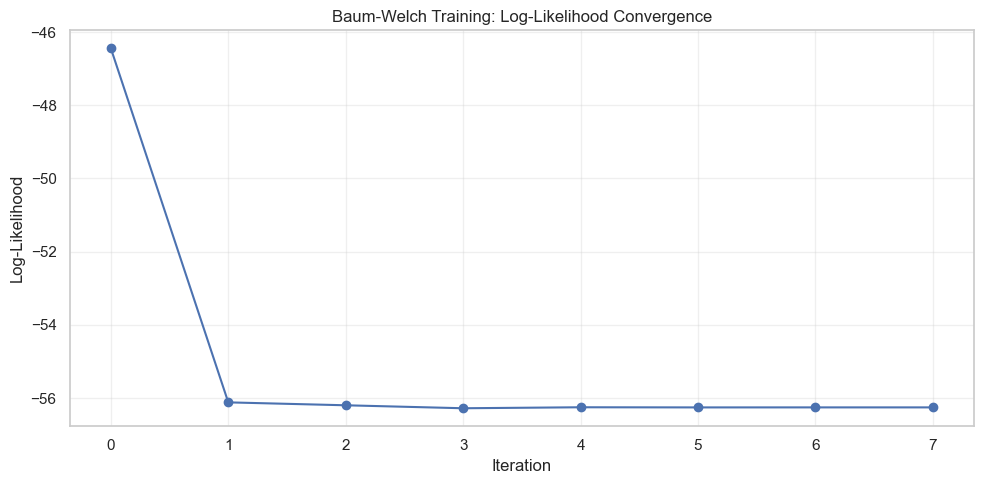

Final log-likelihood: -56.26
Converged in 8 iterations


In [71]:
# Plot training log-likelihood
plt.figure(figsize=(10, 5))
plt.plot(hmm.log_likelihoods, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('Baum-Welch Training: Log-Likelihood Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Final log-likelihood: {hmm.log_likelihoods[-1]:.2f}")
print(f"Converged in {len(hmm.log_likelihoods)} iterations")

## 6. Visualize Transition Matrix

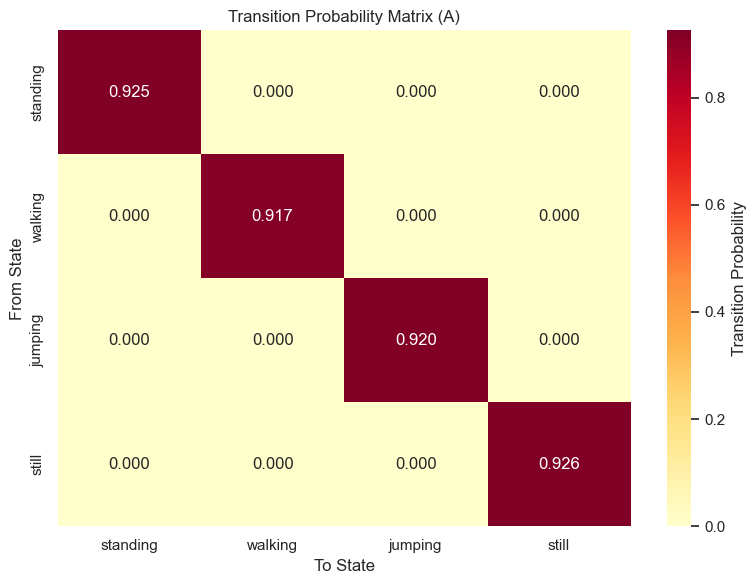


**Transition Matrix Interpretation:**
â€¢ From standing   â†’ Most likely to: standing   (0.925)
â€¢ From walking    â†’ Most likely to: walking    (0.917)
â€¢ From jumping    â†’ Most likely to: jumping    (0.920)
â€¢ From still      â†’ Most likely to: still      (0.926)


In [72]:
# Plot transition matrix as heatmap
plt.figure(figsize=(8, 6))
activity_labels = [ID_TO_ACTIVITY[i] for i in range(N_STATES)]
sns.heatmap(hmm.A, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=activity_labels, yticklabels=activity_labels,
            cbar_kws={'label': 'Transition Probability'})
plt.xlabel('To State')
plt.ylabel('From State')
plt.title('Transition Probability Matrix (A)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "transition_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n**Transition Matrix Interpretation:**")
for i in range(N_STATES):
    most_likely_next = np.argmax(hmm.A[i])
    print(f"â€¢ From {ID_TO_ACTIVITY[i]:10s} â†’ Most likely to: {ID_TO_ACTIVITY[most_likely_next]:10s} ({hmm.A[i, most_likely_next]:.3f})")

## 7. Visualize Emission Probabilities

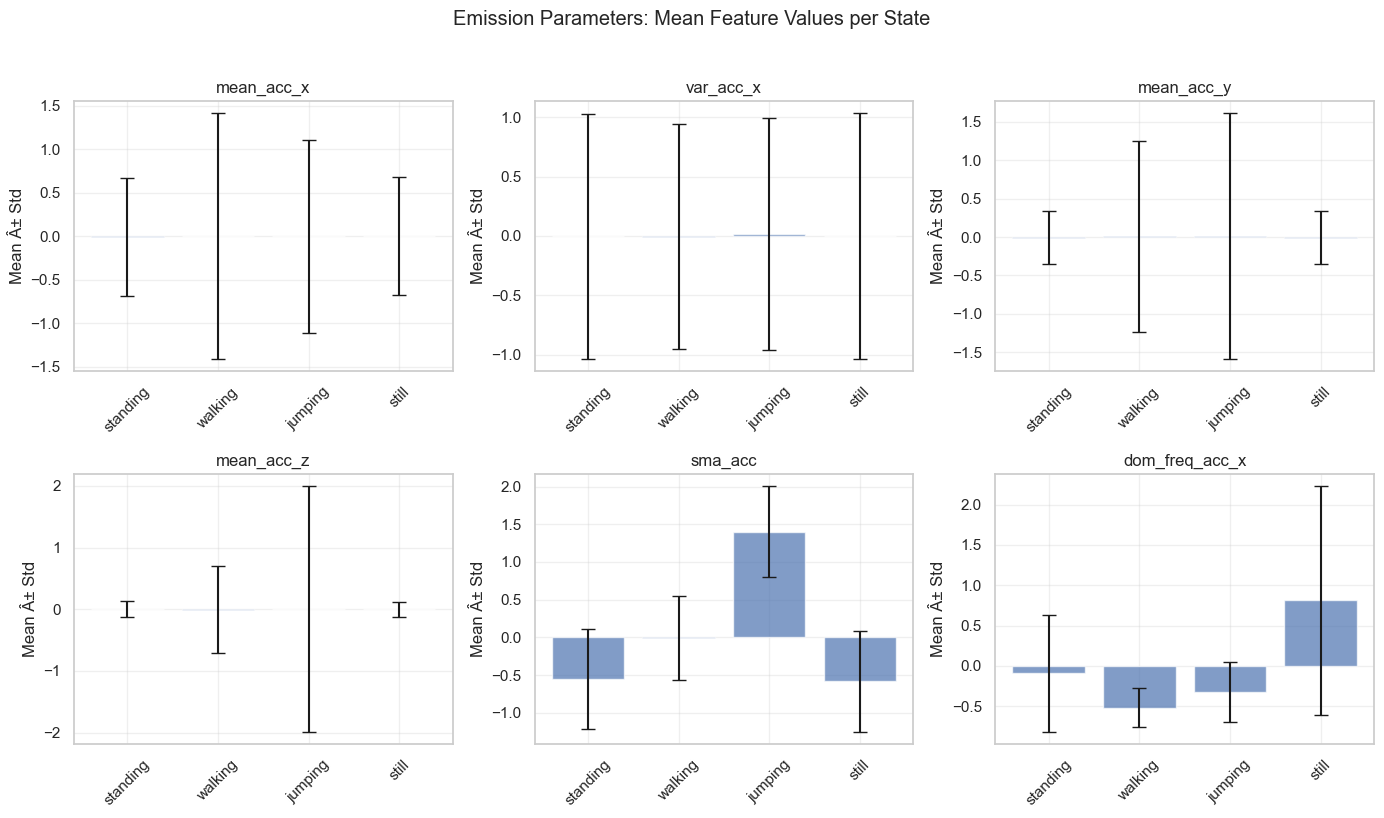

In [73]:
# Visualize emission parameters (mean feature values per state)
# Select top features for visualization
selected_features = ['mean_acc_x', 'mean_acc_y', 'mean_acc_z', 
                     'var_acc_x', 'sma_acc', 'dom_freq_acc_x']
selected_indices = [i for i, name in enumerate(FEATURE_NAMES) if name in selected_features]

if len(selected_indices) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    for idx, feat_idx in enumerate(selected_indices[:6]):
        feat_name = FEATURE_NAMES[feat_idx]
        means = [hmm.means[s, feat_idx] for s in range(N_STATES)]
        stds = [np.sqrt(hmm.covs[s, feat_idx, feat_idx]) for s in range(N_STATES)]
        
        axes[idx].bar(activity_labels, means, yerr=stds, capsize=5, alpha=0.7)
        axes[idx].set_title(f'{feat_name}')
        axes[idx].set_ylabel('Mean Â± Std')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].grid(True, alpha=0.3)
    
    plt.suptitle('Emission Parameters: Mean Feature Values per State', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "emission_parameters.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Warning: Selected features not found in feature names")

## 8. Visualize Decoded Sequences (Training Examples)

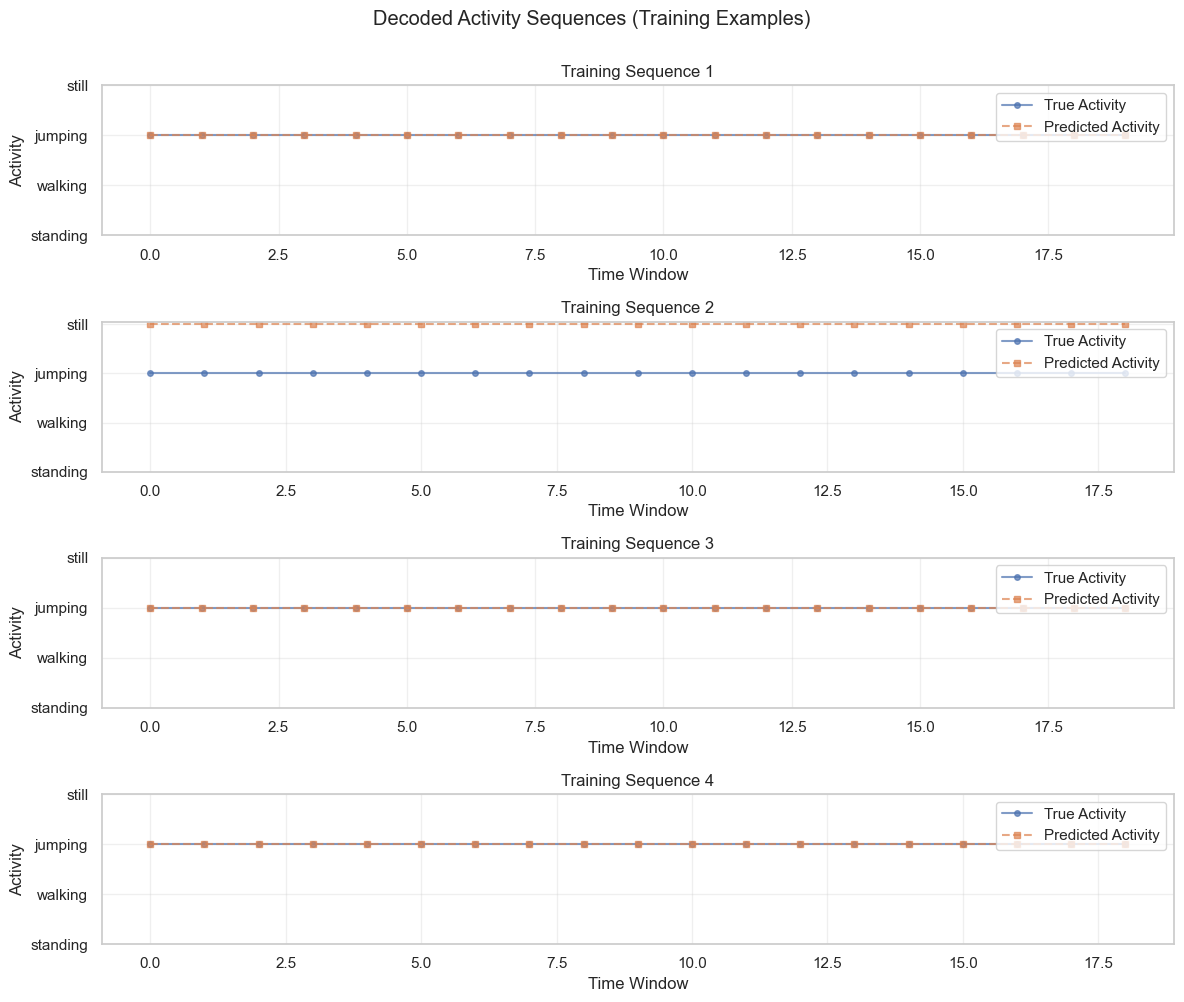

In [74]:
# Plot decoded sequences for a few training examples
n_examples = min(4, len(train_sequences))
fig, axes = plt.subplots(n_examples, 1, figsize=(12, 2.5 * n_examples))
if n_examples == 1:
    axes = [axes]

for idx in range(n_examples):
    obs_seq, true_labels = train_sequences[idx]
    predicted_labels = hmm.predict(obs_seq)
    
    time_steps = np.arange(len(obs_seq))
    
    # Plot true and predicted
    axes[idx].plot(time_steps, true_labels, 'o-', label='True Activity', alpha=0.7, markersize=4)
    axes[idx].plot(time_steps, predicted_labels, 's--', label='Predicted Activity', alpha=0.7, markersize=4)
    axes[idx].set_yticks(range(N_STATES))
    axes[idx].set_yticklabels(activity_labels)
    axes[idx].set_xlabel('Time Window')
    axes[idx].set_ylabel('Activity')
    axes[idx].set_title(f'Training Sequence {idx + 1}')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Decoded Activity Sequences (Training Examples)', y=1.00)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decoded_sequences_training.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evaluation on Unseen Test Data

**Test Data Description:** 
The test data consists of recordings from `raw_data2` that were NOT used during training. These represent unseen recordings from a different session/person to test model generalization.

In [75]:
# Evaluate on test data
print(f"Evaluating on {len(test_sequences)} unseen test sequences...")

all_true_labels = []
all_predicted_labels = []

for obs_seq, true_labels in test_sequences:
    predicted_labels = hmm.predict(obs_seq)
    all_true_labels.extend(true_labels)
    all_predicted_labels.extend(predicted_labels)

all_true_labels = np.array(all_true_labels)
all_predicted_labels = np.array(all_predicted_labels)

print(f"Total test samples: {len(all_true_labels)}")
print(f"Unique true labels: {np.unique(all_true_labels)}")
print(f"Unique predicted labels: {np.unique(all_predicted_labels)}")
print(f"âœ“ Decoding completed")

Evaluating on 4 unseen test sequences...
Total test samples: 79
Unique true labels: [0 1 2 3]
Unique predicted labels: [0 1 3]
âœ“ Decoding completed


## 10. Confusion Matrix

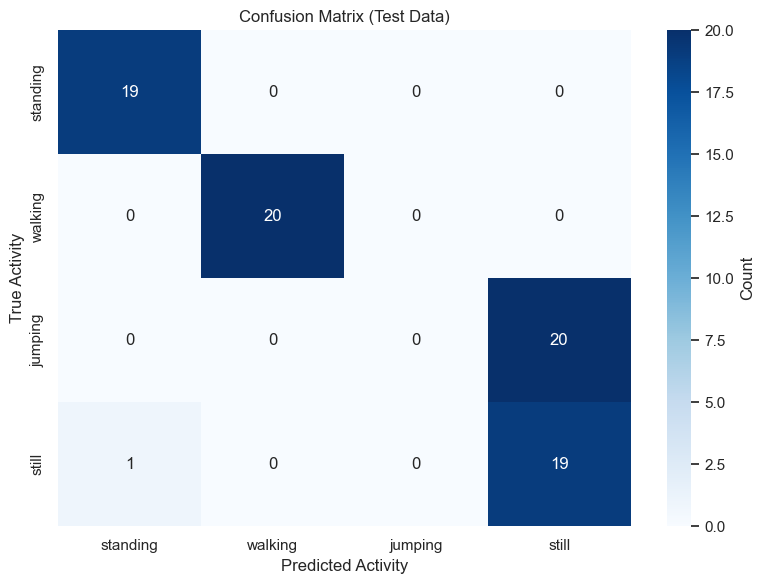

Confusion Matrix:
          standing  walking  jumping  still
standing        19        0        0      0
walking          0       20        0      0
jumping          0        0        0     20
still            1        0        0     19


In [76]:
# Compute confusion matrix
cm = confusion_matrix(all_true_labels, all_predicted_labels, labels=list(range(N_STATES)))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=activity_labels, yticklabels=activity_labels,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')
plt.title('Confusion Matrix (Test Data)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Confusion Matrix:")
print(pd.DataFrame(cm, index=activity_labels, columns=activity_labels))

## 11. Calculate Performance Metrics

In [77]:
def calculate_metrics(y_true, y_pred, n_states):
    """
    Calculate sensitivity, specificity, and accuracy for each state.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        n_states: Number of states
        
    Returns:
        DataFrame with metrics per state
    """
    metrics = []
    
    for state in range(n_states):
        # Binary classification: state vs all others
        true_positive = np.sum((y_true == state) & (y_pred == state))
        false_positive = np.sum((y_true != state) & (y_pred == state))
        true_negative = np.sum((y_true != state) & (y_pred != state))
        false_negative = np.sum((y_true == state) & (y_pred != state))
        
        # Sensitivity (True Positive Rate / Recall)
        sensitivity = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
        
        # Specificity (True Negative Rate)
        specificity = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0
        
        # Accuracy
        accuracy = (true_positive + true_negative) / len(y_true)
        
        # Number of samples
        n_samples = np.sum(y_true == state)
        
        metrics.append({
            'State (Activity)': ID_TO_ACTIVITY[state],
            'Number of Samples': n_samples,
            'Sensitivity': f"{sensitivity:.3f}",
            'Specificity': f"{specificity:.3f}",
            'Overall Accuracy': f"{accuracy:.3f}"
        })
    
    return pd.DataFrame(metrics)

# Calculate metrics
metrics_df = calculate_metrics(all_true_labels, all_predicted_labels, N_STATES)

print("\n" + "="*80)
print("EVALUATION METRICS (UNSEEN TEST DATA)")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)

# Overall accuracy
overall_accuracy = accuracy_score(all_true_labels, all_predicted_labels)
print(f"\nOverall Model Accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")

# Save metrics to CSV
metrics_df.to_csv(OUTPUT_DIR / "evaluation_metrics.csv", index=False)
print(f"\nâœ“ Metrics saved to {OUTPUT_DIR / 'evaluation_metrics.csv'}")


EVALUATION METRICS (UNSEEN TEST DATA)
State (Activity)  Number of Samples Sensitivity Specificity Overall Accuracy
        standing                 19       1.000       0.983            0.987
         walking                 20       1.000       1.000            1.000
         jumping                 20       0.000       1.000            0.747
           still                 20       0.950       0.661            0.734

Overall Model Accuracy: 0.734 (73.4%)

âœ“ Metrics saved to /Users/jade/Hidden_Markov_Models/data/processed/evaluation_metrics.csv


## 12. Visualize Test Decoded Sequences

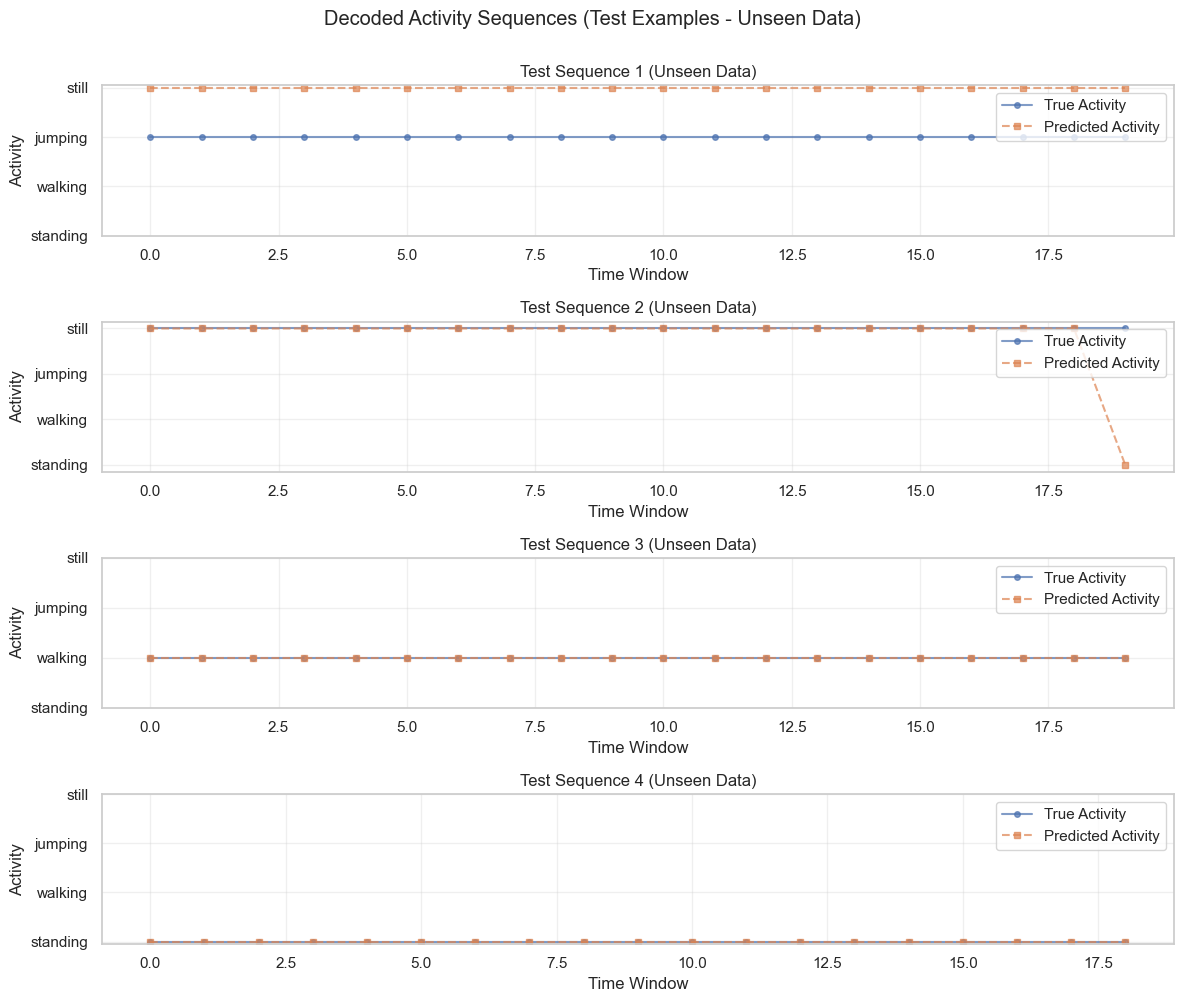

In [78]:
# Plot decoded sequences for test examples
n_test_examples = min(4, len(test_sequences))
fig, axes = plt.subplots(n_test_examples, 1, figsize=(12, 2.5 * n_test_examples))
if n_test_examples == 1:
    axes = [axes]

for idx in range(n_test_examples):
    obs_seq, true_labels = test_sequences[idx]
    predicted_labels = hmm.predict(obs_seq)
    
    time_steps = np.arange(len(obs_seq))
    
    # Plot true and predicted
    axes[idx].plot(time_steps, true_labels, 'o-', label='True Activity', alpha=0.7, markersize=4)
    axes[idx].plot(time_steps, predicted_labels, 's--', label='Predicted Activity', alpha=0.7, markersize=4)
    axes[idx].set_yticks(range(N_STATES))
    axes[idx].set_yticklabels(activity_labels)
    axes[idx].set_xlabel('Time Window')
    axes[idx].set_ylabel('Activity')
    axes[idx].set_title(f'Test Sequence {idx + 1} (Unseen Data)')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Decoded Activity Sequences (Test Examples - Unseen Data)', y=1.00)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decoded_sequences_test.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Analysis and Discussion

In [79]:
# Analyze which activities are easiest/hardest to distinguish
print("\n" + "="*80)
print("ACTIVITY CLASSIFICATION ANALYSIS")
print("="*80)

# Per-class accuracy from confusion matrix
for i in range(N_STATES):
    correct = cm[i, i]
    total = cm[i].sum()
    accuracy = correct / total if total > 0 else 0
    print(f"\n{ID_TO_ACTIVITY[i].upper()}:")
    print(f"  â€¢ Correct predictions: {correct}/{total} ({accuracy*100:.1f}%)")
    
    if total > 0:
        # Most common misclassifications
        misclassified = [(j, cm[i, j]) for j in range(N_STATES) if j != i and cm[i, j] > 0]
        misclassified.sort(key=lambda x: x[1], reverse=True)
        
        if misclassified:
            print(f"  â€¢ Most confused with:")
            for j, count in misclassified[:2]:
                print(f"    - {ID_TO_ACTIVITY[j]}: {count} times ({count/total*100:.1f}%)")

print("\n" + "="*80)


ACTIVITY CLASSIFICATION ANALYSIS

STANDING:
  â€¢ Correct predictions: 19/19 (100.0%)

WALKING:
  â€¢ Correct predictions: 20/20 (100.0%)

JUMPING:
  â€¢ Correct predictions: 0/20 (0.0%)
  â€¢ Most confused with:
    - still: 20 times (100.0%)

STILL:
  â€¢ Correct predictions: 19/20 (95.0%)
  â€¢ Most confused with:
    - standing: 1 times (5.0%)



## 15. Save Final Model

In [80]:
# Save trained model
with open(OUTPUT_DIR / "trained_hmm_model.pkl", "wb") as f:
    pickle.dump(hmm, f)

print(f"âœ“ Trained HMM model saved to {OUTPUT_DIR / 'trained_hmm_model.pkl'}")
print("\n" + "="*80)
print("PART 2 COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  â€¢ trained_hmm_model.pkl")
print("  â€¢ training_convergence.png")
print("  â€¢ transition_matrix.png")
print("  â€¢ emission_parameters.png")
print("  â€¢ decoded_sequences_training.png")
print("  â€¢ decoded_sequences_test.png")
print("  â€¢ confusion_matrix.png")
print("  â€¢ evaluation_metrics.csv")
print("\nAll visualizations and metrics are ready for your report!")

âœ“ Trained HMM model saved to /Users/jade/Hidden_Markov_Models/data/processed/trained_hmm_model.pkl

PART 2 COMPLETE!

Generated files:
  â€¢ trained_hmm_model.pkl
  â€¢ training_convergence.png
  â€¢ transition_matrix.png
  â€¢ emission_parameters.png
  â€¢ decoded_sequences_training.png
  â€¢ decoded_sequences_test.png
  â€¢ confusion_matrix.png
  â€¢ evaluation_metrics.csv

All visualizations and metrics are ready for your report!
